In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.fft import fft2, ifft2, fftshift, ifftshift
import torch

/home/xz127/anaconda3/envs/neuws/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
VERSION = 32 # Version number for the code

AP_L = 60  # Long axis of rectangular aperture
AP_W = int(AP_L/10) # Short axis of rectangular aperture (equivalent to 20cm, keeping 10:1 ratio)
N_APERTURES = 16    # Number of different rotation angles to use
ANGLES = np.linspace(0, 180, N_APERTURES, endpoint=False)
LENGTH = 1024 # Length of the image
WIDTH = 512
C_SIZE = 1200 # canvas size
H_NUM = 2   # Number of rows for plotting
W_NUM = 8   # Number of columns for plotting

IMG_PATH = '/home/xz127/earth_project/Reconstruction/test3_1600_1200.jpg'
SAVE_PATH = f'/home/xz127/earth_project/Reconstruction/{N_APERTURES}AP_combined_result_v{VERSION}.jpg'

In [3]:
def fft_for_plot(fft, epi=1e-10):
    data_plot = np.log(np.abs(fft) + epi) / np.max(np.log(np.abs(fft) + epi))
    return data_plot

In [4]:
def crop_center(img, cropx=50, cropy=50):
    # 1. 无论几通道，前两个维度永远是高度(y)和宽度(x)
    y, x = img.shape[:2]
    startx = x // 2 - (cropx // 2)
    starty = y // 2 - (cropy // 2)    
    
    # 2. 判断图像的维度
    if img.ndim == 3:
        # 如果是 3 维（多通道），保留原有的切片方式 [H, W, C]
        return img[starty:starty+cropy, startx:startx+cropx, :]
    elif img.ndim == 2:
        # 如果是 2 维（单通道），去掉最后一个维度的冒号 [H, W]
        return img[starty:starty+cropy, startx:startx+cropx]
    else:
        # 兜底处理：如果传入的数据既不是2维也不是3维，抛出错误提示
        raise ValueError(f"不符合要求的数组维度：{img.ndim}。该函数仅支持2维或3维数组。")

In [5]:
def get_single_weight_map(phi_ap_degrees, L=LENGTH, W=WIDTH, canvas_size=C_SIZE):
    """
    Generates a binary spatial domain weight map for a rotated rectangular aperture.
    """
    phi_degrees = phi_ap_degrees + 90
    canvas_cx, canvas_cy = canvas_size // 2, canvas_size // 2

    rect_points = np.array([
        [-L / 2, -W / 2],
        [L / 2, -W / 2],
        [L / 2, W / 2],
        [-L / 2, W / 2]
    ])

    phi_rad = np.radians(phi_degrees)
    cos_phi = np.cos(phi_rad)
    sin_phi = np.sin(phi_rad)
    rot_mat = np.array([
        [cos_phi, -sin_phi],
        [sin_phi,  cos_phi]
    ])

    rotated_points = np.dot(rect_points, rot_mat.T) + [canvas_cx, canvas_cy]
    rotated_points = rotated_points.astype(np.int32)

    mask = np.zeros((canvas_size, canvas_size), dtype=np.float32)
    cv2.fillPoly(mask, [rotated_points], 1.0)

    return mask

In [6]:
def compute_positive_diff(A, B):
    """
    计算两个相同尺寸二维数组 A 和 B 的差值 (A - B)，
    保留大于 0 的像素，其余地方置为 0。
    并输出处理后的矩阵、保留像素的最大值和均值。
    """
    # 1. 计算差值
    diff = A - B
    
    # 2. 保留大于0的值，其余地方变0
    # np.where(条件, 满足条件时的值, 不满足条件时的值)
    processed_arr = np.where(diff > 0, diff, 0)
    
    # 3. 提取所有大于0的保留像素（用于计算最大值和均值）
    retained_pixels = diff[diff > 0]
    
    # 4. 计算最大值和均值（需要考虑可能没有像素大于0的极端情况）
    if len(retained_pixels) > 0:
        max_val = np.max(retained_pixels)
        mean_val = np.mean(retained_pixels)
    else:
        # 如果没有任何像素大于0
        max_val = 0.0
        mean_val = 0.0
        
    return processed_arr, max_val, mean_val

In [7]:
def compute_positive_diff(A, B):
    """
    计算两个相同尺寸二维数组 A 和 B 的差值 (A - B)，
    保留大于 0 的像素，其余地方置为 0。
    并输出处理后的矩阵、保留像素的最大值和均值。
    """
    # 1. 计算差值
    diff = A - B
    
    # 2. 保留大于0的值，其余地方变0
    # np.where(条件, 满足条件时的值, 不满足条件时的值)
    processed_arr = np.where(diff > 0, diff, 0)
    
    # 3. 提取所有大于0的保留像素（用于计算最大值和均值）
    retained_pixels = diff[diff > 0]
    
    # 4. 计算最大值和均值（需要考虑可能没有像素大于0的极端情况）
    if len(retained_pixels) > 0:
        max_val = np.max(retained_pixels)
        mean_val = np.mean(retained_pixels)
    else:
        # 如果没有任何像素大于0
        max_val = 0.0
        mean_val = 0.0
        
    return diff, processed_arr, max_val, mean_val, len(retained_pixels)

In [8]:
def get_combination_masks_not_equal(angle_list_deg, canvas_H=C_SIZE, canvas_W=C_SIZE):
    """
    Generates a list of bow-tie (butterfly) frequency-domain masks, one per input angle.
    Each mask's angular extent is bounded by the bisectors with its neighboring angles
    (in the mod-180° sense).

    Args:
        canvas_H (int): Height of the frequency grid.
        canvas_W (int): Width of the frequency grid.
        angle_list_deg (list of float): List of aperture rotation angles in degrees.
            Need not be uniformly spaced or within [0, 180).

    Returns:
        list of numpy.ndarray: One binary bow-tie mask per angle, each (canvas_H, canvas_W).
    """
    # Normalize all angles into [0, 180) — bow-tie is π-periodic
    angles_mod = np.array([a % 180 for a in angle_list_deg], dtype=np.float64)
    N = len(angles_mod)

    # Sort by normalized angle to find neighbors
    sorted_indices = np.argsort(angles_mod)
    sorted_angles = angles_mod[sorted_indices]

    # Compute half-widths (to left and right neighbor) for each sorted angle
    half_widths_left = np.zeros(N)
    half_widths_right = np.zeros(N)
    for i in range(N):
        prev_angle = sorted_angles[(i - 1) % N]
        next_angle = sorted_angles[(i + 1) % N]
        cur_angle = sorted_angles[i]

        diff_left = (cur_angle - prev_angle) % 180
        half_widths_left[i] = diff_left / 2.0

        diff_right = (next_angle - cur_angle) % 180
        half_widths_right[i] = diff_right / 2.0

    # Map back to original ordering
    left_for_orig = np.zeros(N)
    right_for_orig = np.zeros(N)
    for i in range(N):
        orig_idx = sorted_indices[i]
        left_for_orig[orig_idx] = half_widths_left[i]
        right_for_orig[orig_idx] = half_widths_right[i]

    # Create coordinate grids centered at zero
    y_coord = np.linspace(-canvas_H / 2, canvas_H / 2, canvas_H)
    x_coord = np.linspace(-canvas_W / 2, canvas_W / 2, canvas_W)
    x, y = np.meshgrid(x_coord, y_coord)

    masks = []
    for j in range(N):
        phi_rad = np.radians(angle_list_deg[j])

        # Rotate coordinates to align with this aperture's local frame
        xr = x * np.cos(phi_rad) + y * np.sin(phi_rad)
        yr = -x * np.sin(phi_rad) + y * np.cos(phi_rad)

        # Local angle relative to the aperture axis
        theta_local = np.arctan2(yr, xr)

        # Map to [-π/2, π/2] via mod π (same logic as original d_i)
        d_signed = ((theta_local + np.pi / 2) % np.pi) - np.pi / 2

        # Asymmetric thresholds: left (negative side) and right (positive side)
        hw_left_rad = np.radians(left_for_orig[j])
        hw_right_rad = np.radians(right_for_orig[j])

        mask = ((d_signed >= -hw_left_rad) & (d_signed <= hw_right_rad)).astype(np.float32)
        masks.append(mask)

    return masks

In [9]:
import numpy as np

def get_combination_masks_not_equal_v2(angle_list_deg, canvas_H=C_SIZE, canvas_W=C_SIZE):
    """
    Generates a list of bow-tie (butterfly) frequency-domain masks, one per input angle.
    Each mask's angular extent is bounded by the bisectors with its neighboring angles
    (in the mod-180 sense).

    After initial mask generation, a coverage-correction pass ensures that every pixel
    is covered by exactly one mask:
      - Pixels covered zero times are assigned to the mask whose central angle is
        angularly closest (in the mod-180 sense).
      - Pixels covered more than once are kept only in the mask whose central angle is
        angularly closest, and removed from all others.

    Args:
        angle_list_deg (list of float): List of aperture rotation angles in degrees.
            Need not be uniformly spaced or within [0, 180).
        canvas_H (int): Height of the frequency grid.
        canvas_W (int): Width of the frequency grid.

    Returns:
        list of numpy.ndarray: One binary (float32) bow-tie mask per angle,
            each of shape (canvas_H, canvas_W), with every pixel covered exactly once.
    """
    # --- Normalize all angles into [0, 180) — bow-tie mask is pi-periodic ---
    angles_mod = np.array([a % 180 for a in angle_list_deg], dtype=np.float64)
    N = len(angles_mod)

    # Sort by normalized angle so we can find left/right neighbors
    sorted_indices = np.argsort(angles_mod)
    sorted_angles = angles_mod[sorted_indices]

    # Compute the half-angular-width toward each neighbor for every sorted angle.
    # The bisector between two adjacent angles (mod 180) halves the gap between them.
    half_widths_left = np.zeros(N)
    half_widths_right = np.zeros(N)
    for i in range(N):
        prev_angle = sorted_angles[(i - 1) % N]
        next_angle = sorted_angles[(i + 1) % N]
        cur_angle  = sorted_angles[i]

        diff_left  = (cur_angle - prev_angle) % 180
        diff_right = (next_angle - cur_angle) % 180

        half_widths_left[i]  = diff_left  / 2.0
        half_widths_right[i] = diff_right / 2.0

    # Map the sorted half-widths back to the original input ordering
    left_for_orig  = np.zeros(N)
    right_for_orig = np.zeros(N)
    for i in range(N):
        orig_idx = sorted_indices[i]
        left_for_orig[orig_idx]  = half_widths_left[i]
        right_for_orig[orig_idx] = half_widths_right[i]

    # Build pixel coordinate grids (origin at center)
    y_coord = np.linspace(-canvas_H / 2, canvas_H / 2, canvas_H)
    x_coord = np.linspace(-canvas_W / 2, canvas_W / 2, canvas_W)
    x, y = np.meshgrid(x_coord, y_coord)

    # --- Pass 1: generate initial masks with the bisector rule ---
    masks = []
    for j in range(N):
        phi_rad = np.radians(angle_list_deg[j])

        # Rotate the pixel grid so the aperture axis aligns with the local x-axis
        xr =  x * np.cos(phi_rad) + y * np.sin(phi_rad)
        yr = -x * np.sin(phi_rad) + y * np.cos(phi_rad)

        # Local signed angle (in [-pi/2, pi/2]) relative to the aperture axis
        theta_local = np.arctan2(yr, xr)
        d_signed = ((theta_local + np.pi / 2) % np.pi) - np.pi / 2

        hw_left_rad  = np.radians(left_for_orig[j])
        hw_right_rad = np.radians(right_for_orig[j])

        mask = ((d_signed >= -hw_left_rad) & (d_signed <= hw_right_rad)).astype(np.float32)
        masks.append(mask)

    # --- Pass 2: coverage correction ---
    # Stack masks into a single 3-D array for efficient per-pixel operations
    mask_stack = np.stack(masks, axis=0)   # shape: (N, H, W)
    coverage   = mask_stack.sum(axis=0)    # number of masks covering each pixel

    # Compute the angular distance from each pixel to each aperture center.
    # We work in the mod-180 angle domain, so the "pixel angle" is arctan2(y, x) mod 180.
    pixel_angle = (np.degrees(np.arctan2(y, x)) % 180)  # (H, W), in [0, 180)

    # Angular distance from every pixel to every aperture (mod-180, symmetric)
    # Result shape: (N, H, W)
    delta = np.abs(pixel_angle[np.newaxis, :, :] - angles_mod[:, np.newaxis, np.newaxis])
    # Wrap so the maximum distance is 90 degrees (half of the 180-degree period)
    angular_dist = np.minimum(delta, 180.0 - delta)

    # Index of the closest aperture for each pixel
    closest = np.argmin(angular_dist, axis=0)  # (H, W)

    # Fix under-covered pixels (coverage == 0): assign to the closest aperture
    under_mask = (coverage == 0)
    if under_mask.any():
        for j in range(N):
            assign = under_mask & (closest == j)
            mask_stack[j][assign] = 1.0

    # Fix over-covered pixels (coverage > 1): keep only the closest aperture
    over_mask = (coverage > 1)
    if over_mask.any():
        for j in range(N):
            # Among over-covered pixels NOT belonging to the closest aperture, clear them
            remove = over_mask & (closest != j) & (mask_stack[j] > 0)
            mask_stack[j][remove] = 0.0

    # Unpack the corrected stack back into a list
    masks_corrected = [mask_stack[j] for j in range(N)]

    # --- Sanity check (raises an AssertionError if correction failed) ---
    final_coverage = np.stack(masks_corrected, axis=0).sum(axis=0)
    assert np.all(final_coverage == 1), (
        f"Coverage correction failed: min={final_coverage.min()}, max={final_coverage.max()}"
    )

    return masks_corrected

In [10]:
fft_save_dir_40 = '/home/xz127/earth_project/Reconstruction/Results/v40/single_results/G_IMG_FFTS'
data_dir_40 = '/home/xz127/earth_project/Reconstruction/Results/v40/single_results'
fft_save_dir_41 = '/home/xz127/earth_project/Reconstruction/Results/v41/single_results/G_IMG_FFTS'
data_dir_41 = '/home/xz127/earth_project/Reconstruction/Results/v41/single_results'

In [11]:
loaded_data_40 = np.load(os.path.join(data_dir_40, "246_fft.npy")) # (0, 1, 2, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15)

loaded_data_41 = np.load(os.path.join(data_dir_41, "246_fft.npy"))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


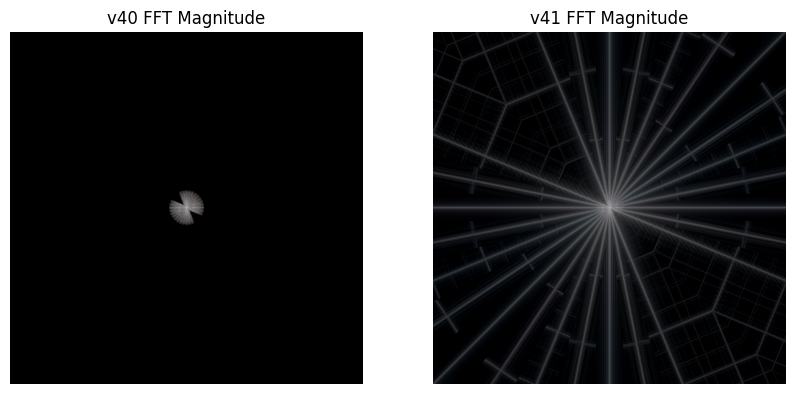

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(fft_for_plot(loaded_data_40), cmap='gray')
axs[0].set_title("v40 FFT Magnitude")
axs[0].axis('off')  
axs[1].imshow(fft_for_plot(loaded_data_41), cmap='gray')
axs[1].set_title("v41 FFT Magnitude")
axs[1].axis('off')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


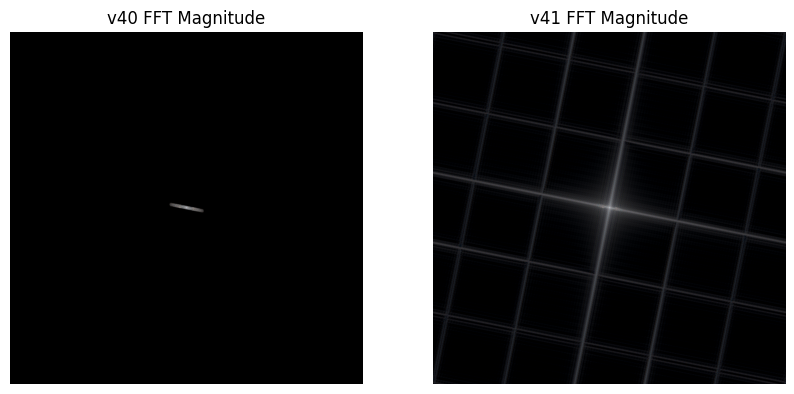

In [13]:
g_fft_1_40 = np.load(os.path.join(fft_save_dir_40, "1_phi11.npy"))
g_fft_1_41 = np.load(os.path.join(fft_save_dir_41, "1_phi11.npy"))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(fft_for_plot(g_fft_1_40), cmap='gray')
axs[0].set_title("v40 FFT Magnitude")
axs[0].axis('off')  
axs[1].imshow(fft_for_plot(g_fft_1_41), cmap='gray')
axs[1].set_title("v41 FFT Magnitude")
axs[1].axis('off')
plt.show()

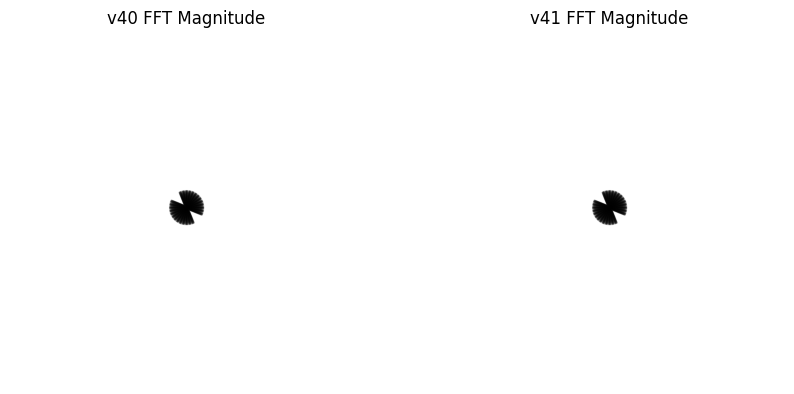

In [14]:
h_40 = np.load(os.path.join(data_dir_40, "246_h_filter.npy")) # (0, 1, 2, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15)

h_41 = np.load(os.path.join(data_dir_41, "246_h_filter.npy"))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(h_40, cmap='gray')
axs[0].set_title("v40 FFT Magnitude")
axs[0].axis('off')  
axs[1].imshow(h_41, cmap='gray')
axs[1].set_title("v41 FFT Magnitude")
axs[1].axis('off')
plt.show()

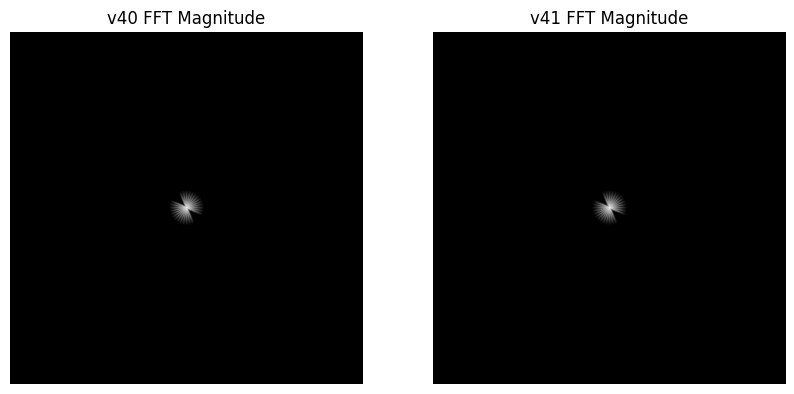

In [15]:
sum_mtf_40 = np.load(os.path.join(data_dir_40, "246_sum_m_mtf.npy")) # (0, 1, 2, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15)

sum_mtf_41 = np.load(os.path.join(data_dir_41, "246_sum_m_mtf.npy"))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(sum_mtf_40, cmap='gray')
axs[0].set_title("v40 FFT Magnitude")
axs[0].axis('off')  
axs[1].imshow(sum_mtf_41, cmap='gray')
axs[1].set_title("v41 FFT Magnitude")
axs[1].axis('off')
plt.show()

In [10]:
# 1. Read the image (Defaults to BGR, uint8)
img_bgr = cv2.imread(IMG_PATH)

# 2. Convert BGR to RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3. Convert to float32 and normalize to [0, 1]
# We use .astype(np.float32) and divide by 255.0
IMG_FULL = img_rgb.astype("float32") / 255.0
GT_IMG = crop_center(IMG_FULL, cropx=C_SIZE, cropy=C_SIZE)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


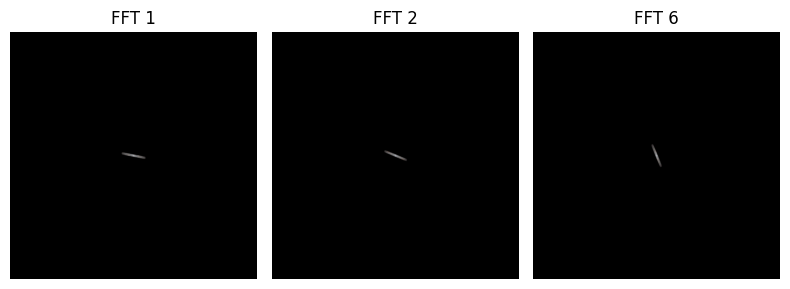

Max value in g_fft_1: 986238.9
mean value in g_fft_1: 1.383368
min value in g_fft_1: 0.0


In [28]:

g_fft_1 = np.load(os.path.join(fft_save_dir, "1_phi11.npy"))
g_fft_2 = np.load(os.path.join(fft_save_dir, "2_phi22.npy"))
g_fft_6 = np.load(os.path.join(fft_save_dir, "6_phi68.npy"))

fft_list = [g_fft_1, g_fft_2, g_fft_6]

fig, axes = plt.subplots(1, 3, figsize=(8, 4))
axes[0].imshow(fft_for_plot(g_fft_1))
axes[0].set_title("FFT 1")
axes[0].axis('off')

axes[1].imshow(fft_for_plot(g_fft_2))
axes[1].set_title("FFT 2")
axes[1].axis('off')

axes[2].imshow(fft_for_plot(g_fft_6))
axes[2].set_title("FFT 6")
axes[2].axis('off') 
plt.tight_layout()
plt.show()

print("Max value in g_fft_1:", np.max(np.abs(g_fft_1)))
print("mean value in g_fft_1:", np.mean(np.abs(g_fft_1)))
print("min value in g_fft_1:", np.min(np.abs(g_fft_1)))

In [47]:
fft_list[0].shape

(1200, 1200, 3)

In [48]:
stacked_fft = np.stack(fft_list, axis=0)
mean_channels = np.mean(stacked_fft[:, 600, 600, :], axis=0)
print(mean_channels)

[826109.6+0.j 914747.7+0.j 982206.1+0.j]


In [23]:
for i, g_fft in enumerate([g_fft_1, g_fft_2, g_fft_6], start=1):
    max_val = np.max(np.abs(g_fft))
    mean_val = np.mean(np.abs(g_fft))
    center_val = np.abs(g_fft[600, 600])
    print(f"FFT {i}: Max={max_val}, Mean={mean_val}, Center={center_val}")

FFT 1: Max=986238.875, Mean=1.3833680152893066, Center=[824596.4 916068.  986238.9]
FFT 2: Max=984022.875, Mean=1.3523075580596924, Center=[823465.9 914505.5 984022.9]
FFT 3: Max=976356.5625, Mean=1.3974114656448364, Center=[830266.56 913669.4  976356.56]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


-----------Angle: 11.25
Value of single fft: [824596.4+0.j 916068. +0.j 986238.9+0.j]
Magnitude of single fft: [824596.4 916068.  986238.9]
Mask value: 0.0
Reconstructed value: [0.+0.j 0.+0.j 0.+0.j]
magnitude of recon: [0. 0. 0.]
-----------Angle: 22.5
Value of single fft: [823465.9+0.j 914505.5+0.j 984022.9+0.j]
Magnitude of single fft: [823465.9 914505.5 984022.9]
Mask value: 1.0
Reconstructed value: [823465.875+0.j 914505.5  +0.j 984022.875+0.j]
magnitude of recon: [823465.875 914505.5   984022.875]
-----------Angle: 67.5
Value of single fft: [830266.56+0.j 913669.4 +0.j 976356.56+0.j]
Magnitude of single fft: [830266.56 913669.4  976356.56]
Mask value: 1.0
Reconstructed value: [1653732.4375+0.j 1828174.875 +0.j 1960379.4375+0.j]
magnitude of recon: [1653732.4375 1828174.875  1960379.4375]


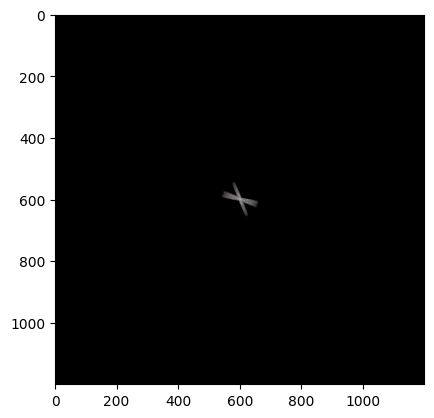

In [34]:
reconstructed_fft = np.zeros((C_SIZE, C_SIZE, 3), dtype=complex)
for i in range(len(angle_list)):
    # Expand 2D mask to 3D using np.newaxis to broadcast across R, G, and Bff
    reconstructed_fft += mask_103[i][:, :, np.newaxis] * fft_list[i]
    print(f"-----------Angle: {angle_list[i]}")
    print(f"Value of single fft: {fft_list[i][600, 600]}")
    print(f"Magnitude of single fft: {np.abs(fft_list[i][600, 600])}")
    print(f"Mask value: {mask_103[i][600, 600]}")
    print(f"Reconstructed value: {reconstructed_fft[600, 600]}")
    print(f"magnitude of recon: {np.abs(reconstructed_fft[600, 600])}")
    
plt.imshow(fft_for_plot(reconstructed_fft), cmap='gray')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


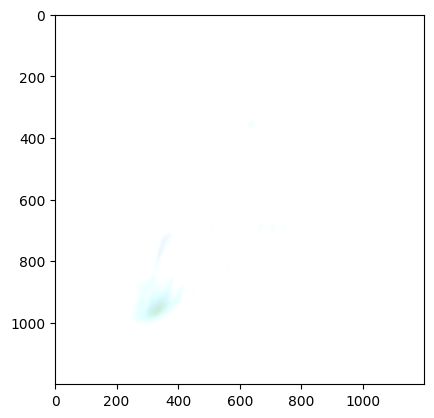

In [35]:
recon_test = np.abs(ifft2(ifftshift(reconstructed_fft, axes=(0, 1)), axes=(0, 1)))
plt.imshow(recon_test)
plt.show()

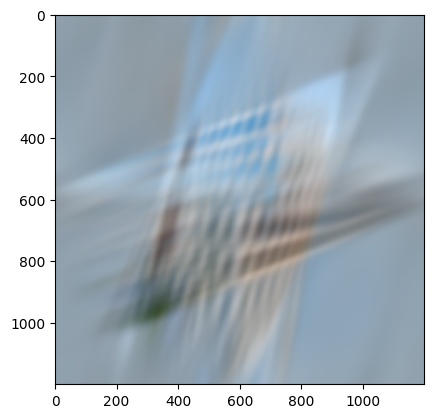

In [49]:
recon_dc_mean = reconstructed_fft.copy()
recon_dc_mean[600, 600, :] = mean_channels
recon_test = np.abs(ifft2(ifftshift(recon_dc_mean, axes=(0, 1)), axes=(0, 1)))
plt.imshow(recon_test)
plt.show()

In [31]:
# 指定图片地址
image_path = "/home/xz127/earth_project/Reconstruction/Results/v37/single_results/103_no_h.jpg"

# 读入图片
# 注意：OpenCV 默认读取的通道顺序是 BGR，而不是 RGB
img_bgr = cv2.imread(image_path)

# 将 BGR 转换为标准的 RGB 格式
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img = img_rgb.astype(np.float32) / 255.0  # 将像素值归一化到 [0, 1] 范围

test = img/np.max(img)

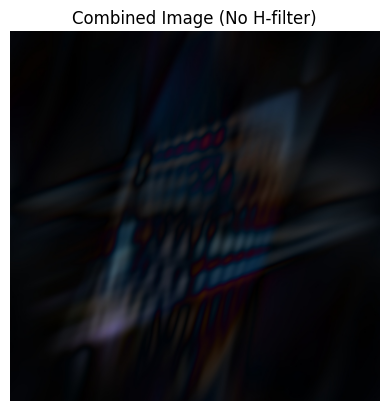

In [11]:
plt.imshow(img)
plt.axis('off')  # 不显示坐标轴
plt.title('Combined Image (No H-filter)')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


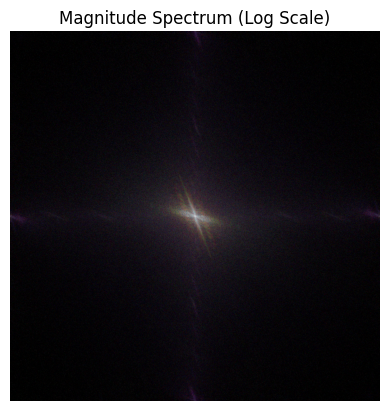

In [32]:
f_transform = np.fft.fft2(img, axes=(0, 1))

# 3. 一行代码搞定三通道的 FFT Shift
# 同样通过 axes=(0, 1) 告诉它只对空间维度进行中心平移
f_shift = np.fft.fftshift(f_transform, axes=(0, 1))


plt.imshow(fft_for_plot(f_shift))
plt.axis('off')  # 不显示坐标轴
plt.title('Magnitude Spectrum (Log Scale)')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Max value in g_fft_103 before adding constant: 48396.887
mean value in g_fft_103 before adding constant: 1.3528154
Min value in g_fft_103 before adding constant: 0.0
Max value in g_fft_103: 48396.887
mean value in g_fft_103: 1.3528154


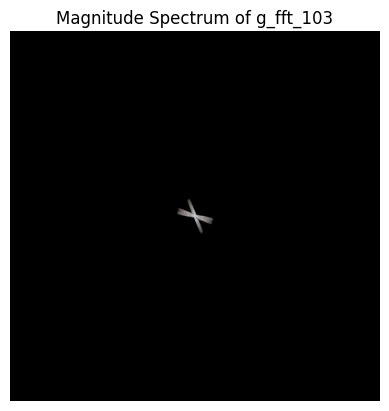

In [13]:
g_fft_103 = np.load(os.path.join(data_dir, "103_fft.npy"))
print("Max value in g_fft_103 before adding constant:", np.max(np.abs(g_fft_103)))
print("mean value in g_fft_103 before adding constant:", np.mean(np.abs(g_fft_103)))
print("Min value in g_fft_103 before adding constant:", np.min(np.abs(g_fft_103)))
g_fft_103 = g_fft_103 + 1e-10  # 添加一个小常数以避免 log(0) 的问题

print("Max value in g_fft_103:", np.max(np.abs(g_fft_103)))
print("mean value in g_fft_103:", np.mean(np.abs(g_fft_103)))

plt.imshow(fft_for_plot(g_fft_103))
plt.axis('off')  # 不显示坐标轴
plt.title('Magnitude Spectrum of g_fft_103')
plt.show()

Max value in g_fft_103 before adding constant: 48396.887
mean value in g_fft_103 before adding constant: 1.3528154
Min value in g_fft_103 before adding constant: 0.0
========== 阈值筛选统计结果 (Threshold = 10000) ==========

[通道 0]
  - 全局最大值: 28431.9707
  - 大于阈值的像素数目: 15 个 / 总像素 1440000 个
  - 大于阈值像素的平均值: 15339.8223

[通道 1]
  - 全局最大值: 33365.0391
  - 大于阈值的像素数目: 11 个 / 总像素 1440000 个
  - 大于阈值像素的平均值: 21260.6426

[通道 2]
  - 全局最大值: 48396.8867
  - 大于阈值的像素数目: 20 个 / 总像素 1440000 个
  - 大于阈值像素的平均值: 21660.9180


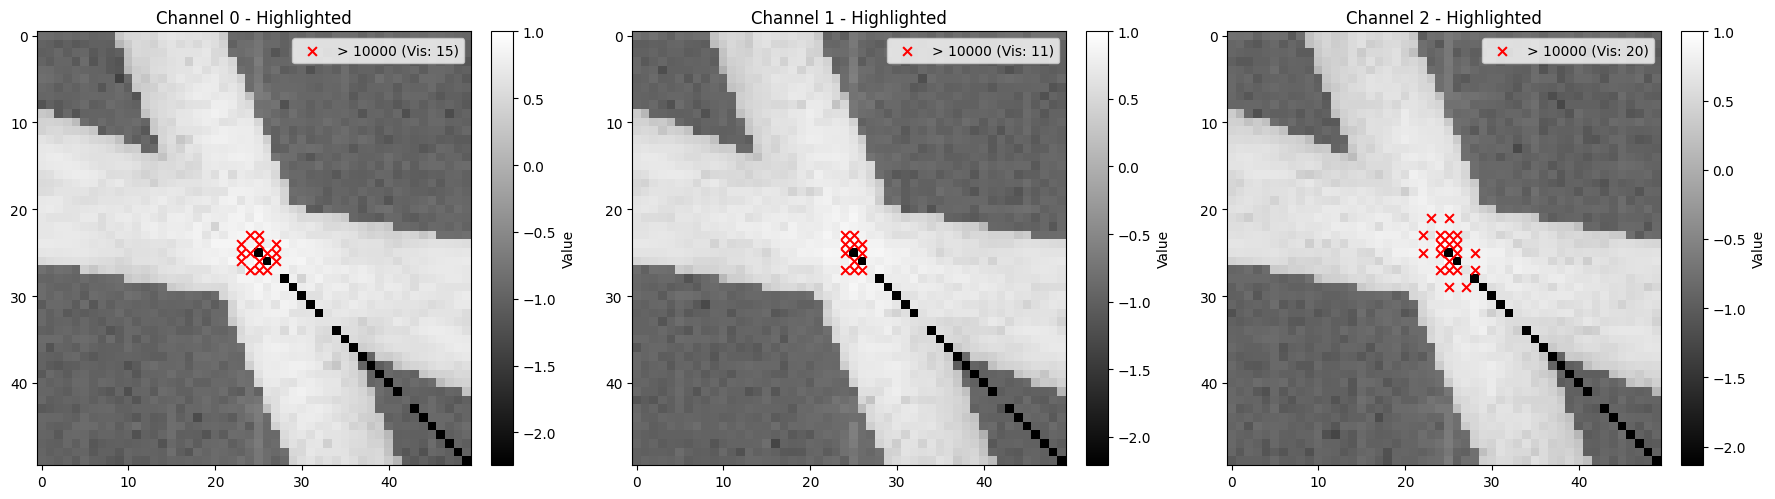

In [65]:
from matplotlib.colors import ListedColormap
g_fft_103 = np.load(os.path.join(data_dir, "103_fft.npy"))
print("Max value in g_fft_103 before adding constant:", np.max(np.abs(g_fft_103)))
print("mean value in g_fft_103 before adding constant:", np.mean(np.abs(g_fft_103)))
print("Min value in g_fft_103 before adding constant:", np.min(np.abs(g_fft_103)))

data_3d = np.abs(g_fft_103)
threshold = 10000
mask_3d = data_3d > threshold

print(f"========== 阈值筛选统计结果 (Threshold = {threshold}) ==========")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ch in range(3):
    channel_data = data_3d[:, :, ch]
    channel_mask = mask_3d[:, :, ch]
    ax = axes[ch]
    pixel_count = np.sum(channel_mask)                     # 大于阈值的像素数目
    max_value = np.max(channel_data)                       # 当前通道的最大值
    if pixel_count > 0:
        mean_value = np.mean(channel_data[channel_mask])
    else:
        mean_value = 0.0
    print(f"\n[通道 {ch}]")
    print(f"  - 全局最大值: {max_value:.4f}")
    print(f"  - 大于阈值的像素数目: {pixel_count} 个 / 总像素 {channel_data.size} 个")
    print(f"  - 大于阈值像素的平均值: {mean_value:.4f}")
    plot_data = crop_center(fft_for_plot(channel_data)) 
    im = ax.imshow(plot_data, cmap='gray', origin='upper')
    fig.colorbar(im, ax=ax, label='Value', fraction=0.046, pad=0.04)
    cropped_mask = crop_center(channel_mask)
    y_indices, x_indices = np.where(cropped_mask)
    if len(x_indices) > 0:
        ax.scatter(x_indices, y_indices, color='red', marker='x', s=40, 
                   label=f'> {threshold} (Vis: {len(x_indices)})')
        ax.legend(loc='upper right')
    ax.set_title(f'Channel {ch} - Highlighted')
plt.tight_layout()
plt.show()

In [66]:
print(g_fft_103[600,600])

[0.+0.j 0.+0.j 0.+0.j]


Max value in g_fft_99 before adding constant: 978298.25
mean value in g_fft_99 before adding constant: 1.8884971
Min value in g_fft_99 before adding constant: 0.0
========== 阈值筛选统计结果 (Threshold = 10000) ==========

[通道 0]
  - 全局最大值: 829219.5000
  - 大于阈值的像素数目: 14 个 / 总像素 1440000 个
  - 大于阈值像素的平均值: 73634.1719

[通道 1]
  - 全局最大值: 914276.8750
  - 大于阈值的像素数目: 11 个 / 总像素 1440000 个
  - 大于阈值像素的平均值: 101389.3438

[通道 2]
  - 全局最大值: 978298.2500
  - 大于阈值的像素数目: 21 个 / 总像素 1440000 个
  - 大于阈值像素的平均值: 65113.6328


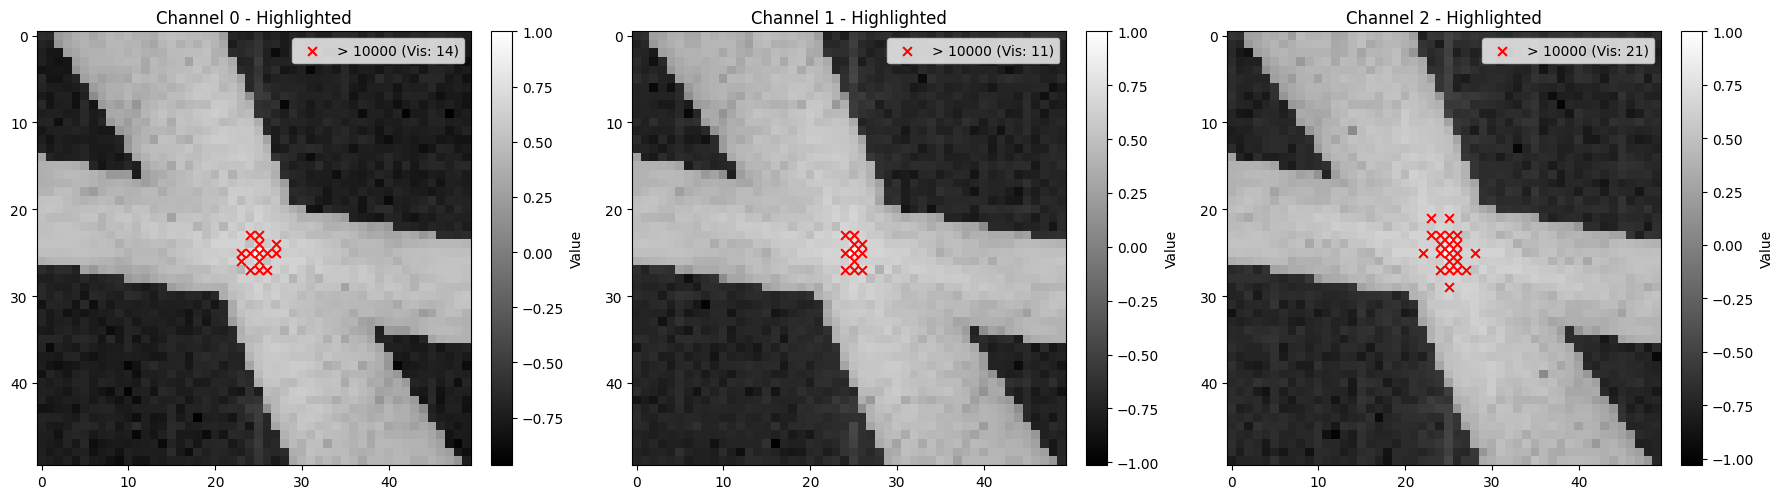

In [15]:
from matplotlib.colors import ListedColormap
g_fft_99 = np.load(os.path.join(data_dir, "99_fft.npy"))
print("Max value in g_fft_99 before adding constant:", np.max(np.abs(g_fft_99))) #group 99: (1,5,6)
print("mean value in g_fft_99 before adding constant:", np.mean(np.abs(g_fft_99)))
print("Min value in g_fft_99 before adding constant:", np.min(np.abs(g_fft_99)))

data_3d = np.abs(g_fft_99)
threshold = 10000
mask_3d = data_3d > threshold

print(f"========== 阈值筛选统计结果 (Threshold = {threshold}) ==========")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ch in range(3):
    channel_data = data_3d[:, :, ch]
    channel_mask = mask_3d[:, :, ch]
    ax = axes[ch]
    pixel_count = np.sum(channel_mask)                     # 大于阈值的像素数目
    max_value = np.max(channel_data)                       # 当前通道的最大值
    if pixel_count > 0:
        mean_value = np.mean(channel_data[channel_mask])
    else:
        mean_value = 0.0
    print(f"\n[通道 {ch}]")
    print(f"  - 全局最大值: {max_value:.4f}")
    print(f"  - 大于阈值的像素数目: {pixel_count} 个 / 总像素 {channel_data.size} 个")
    print(f"  - 大于阈值像素的平均值: {mean_value:.4f}")
    plot_data = crop_center(fft_for_plot(channel_data)) 
    im = ax.imshow(plot_data, cmap='gray', origin='upper')
    fig.colorbar(im, ax=ax, label='Value', fraction=0.046, pad=0.04)
    cropped_mask = crop_center(channel_mask)
    y_indices, x_indices = np.where(cropped_mask)
    if len(x_indices) > 0:
        ax.scatter(x_indices, y_indices, color='red', marker='x', s=40, 
                   label=f'> {threshold} (Vis: {len(x_indices)})')
        ax.legend(loc='upper right')
    ax.set_title(f'Channel {ch} - Highlighted')
plt.tight_layout()
plt.show()

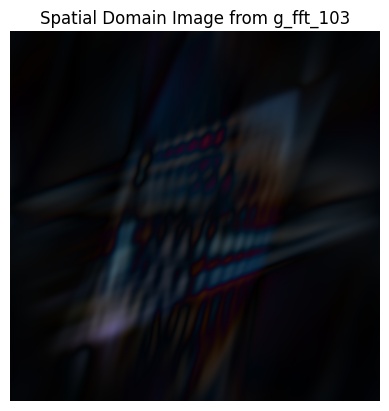

Max value in spatial_test: 0.4712489


In [16]:
spatial_test = np.abs(ifft2(ifftshift(g_fft_103, axes=(0, 1)), axes=(0, 1)))
fft_back = fftshift(fft2(spatial_test, axes=(0, 1)), axes=(0, 1))
plt.imshow(spatial_test)
plt.axis('off')  # 不显示坐标轴 
plt.title('Spatial Domain Image from g_fft_103')
plt.show()

print("Max value in spatial_test:", np.max(spatial_test))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Max value in fft_back: 95676.17
mean value in fft_back: 1.7030475


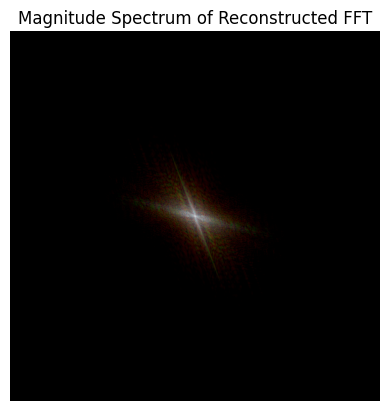

In [17]:
print("Max value in fft_back:", np.max(np.abs(fft_back)))
print("mean value in fft_back:", np.mean(np.abs(fft_back)))

plt.imshow(fft_for_plot(fft_back))
plt.axis('off')  # 不显示坐标轴
plt.title('Magnitude Spectrum of Reconstructed FFT')
plt.show()




In [18]:
print(np.abs(g_fft_103[600, 600, :]))

[0. 0. 0.]


Max value in g_fft_1 before adding constant: 986238.9
mean value in g_fft_1 before adding constant: 1.383368
Min value in g_fft_1 before adding constant: 0.0
========== 阈值筛选统计结果 (Threshold = 100000) ==========

[通道 0]
  - 全局最大值: 824596.3750
  - 大于阈值的像素数目: 1 个 / 总像素 1440000 个
  - 大于阈值像素的平均值: 824596.3750
  - 原图对应坐标 (Y, X): [(600, 600)]

[通道 1]
  - 全局最大值: 916068.0000
  - 大于阈值的像素数目: 1 个 / 总像素 1440000 个
  - 大于阈值像素的平均值: 916068.0000
  - 原图对应坐标 (Y, X): [(600, 600)]

[通道 2]
  - 全局最大值: 986238.8750
  - 大于阈值的像素数目: 1 个 / 总像素 1440000 个
  - 大于阈值像素的平均值: 986238.8750
  - 原图对应坐标 (Y, X): [(600, 600)]


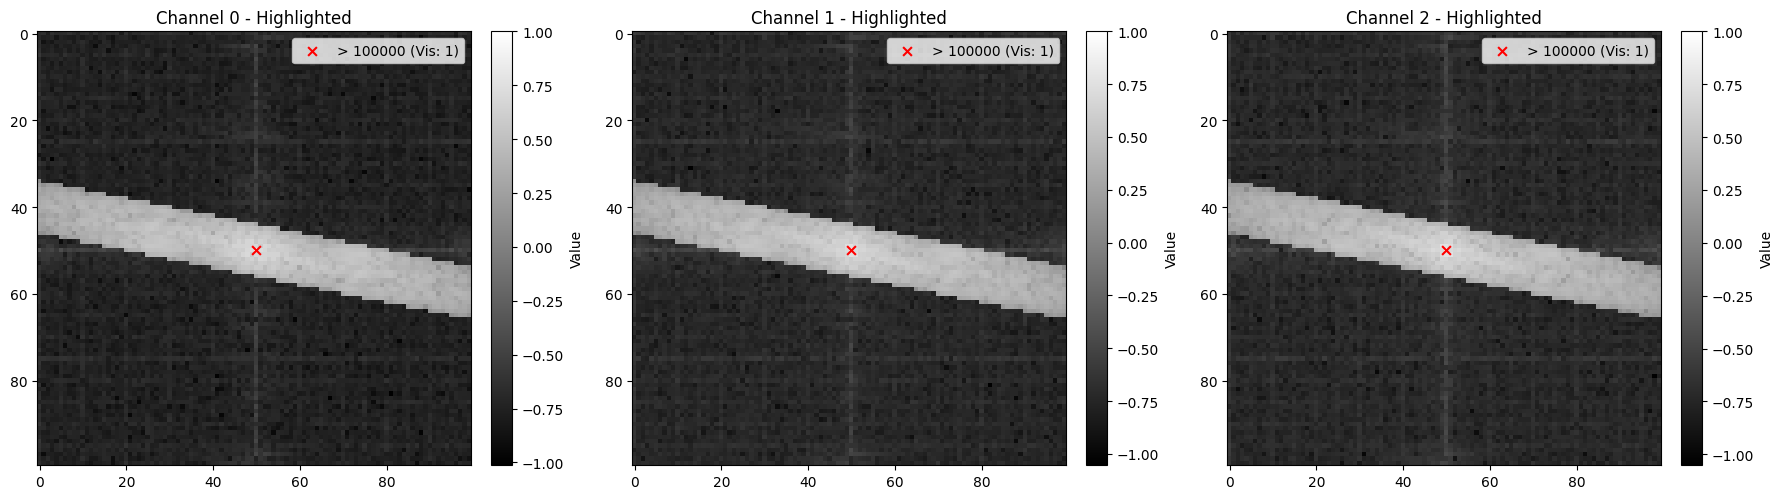

In [21]:
from matplotlib.colors import ListedColormap
import io

print("Max value in g_fft_1 before adding constant:", np.max(np.abs(g_fft_1)))
print("mean value in g_fft_1 before adding constant:", np.mean(np.abs(g_fft_1)))
print("Min value in g_fft_1 before adding constant:", np.min(np.abs(g_fft_1)))

data_3d = np.abs(g_fft_1)
threshold = 100000
mask_3d = data_3d > threshold

print(f"========== 阈值筛选统计结果 (Threshold = {threshold}) ==========")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

saved_plots_list = []

for ch in range(3):
    channel_data = data_3d[:, :, ch]
    channel_mask = mask_3d[:, :, ch]
    ax = axes[ch]
    pixel_count = np.sum(channel_mask)                     # 大于阈值的像素数目
    max_value = np.max(channel_data)                       # 当前通道的最大值
    if pixel_count > 0:
        mean_value = np.mean(channel_data[channel_mask])
    else:
        mean_value = 0.0
    print(f"\n[通道 {ch}]")
    print(f"  - 全局最大值: {max_value:.4f}")
    print(f"  - 大于阈值的像素数目: {pixel_count} 个 / 总像素 {channel_data.size} 个")
    print(f"  - 大于阈值像素的平均值: {mean_value:.4f}")
    
    orig_y, orig_x = np.where(channel_mask)
    if len(orig_x) > 0:
        # 将坐标打包成 (Y, X) 或者是 (row, col) 的元组列表
        orig_coords = list(zip(orig_y.tolist(), orig_x.tolist()))
        
        # 为了防止坐标太多刷屏，这里限制最多打印前 10 个
        max_print_num = 10
        coords_str = ", ".join([str(c) for c in orig_coords[:max_print_num]])
        
        if len(orig_coords) > max_print_num:
            print(f"  - 原图对应坐标 (Y, X): [{coords_str}, ... 等共 {len(orig_coords)} 个坐标]")
        else:
            print(f"  - 原图对应坐标 (Y, X): [{coords_str}]")
    else:
        print("  - 原图对应坐标 (Y, X): [] (无满足条件的像素)")
        
    plot_data = crop_center(fft_for_plot(channel_data), cropx=100, cropy=100) 
    im = ax.imshow(plot_data, cmap='gray', origin='upper')
    fig.colorbar(im, ax=ax, label='Value', fraction=0.046, pad=0.04)
    cropped_mask = crop_center(channel_mask, cropx=100, cropy=100)
    y_indices, x_indices = np.where(cropped_mask)
    if len(x_indices) > 0:
        ax.scatter(x_indices, y_indices, color='red', marker='x', s=40, 
                   label=f'> {threshold} (Vis: {len(x_indices)})')
        ax.legend(loc='upper right')
    ax.set_title(f'Channel {ch} - Highlighted')
plt.tight_layout()
plt.show()

Max value in g_fft_2 before adding constant: 984022.9
mean value in g_fft_2 before adding constant: 1.3523076
Min value in g_fft_2 before adding constant: 0.0
========== 阈值筛选统计结果 (Threshold = 100000) ==========

[通道 0]
  - 全局最大值: 823465.8750
  - 大于阈值的像素数目: 1 个 / 总像素 1440000 个
  - 大于阈值像素的平均值: 823465.8750
  - 原图对应坐标 (Y, X): [(600, 600)]

[通道 1]
  - 全局最大值: 914505.5000
  - 大于阈值的像素数目: 1 个 / 总像素 1440000 个
  - 大于阈值像素的平均值: 914505.5000
  - 原图对应坐标 (Y, X): [(600, 600)]

[通道 2]
  - 全局最大值: 984022.8750
  - 大于阈值的像素数目: 1 个 / 总像素 1440000 个
  - 大于阈值像素的平均值: 984022.8750
  - 原图对应坐标 (Y, X): [(600, 600)]


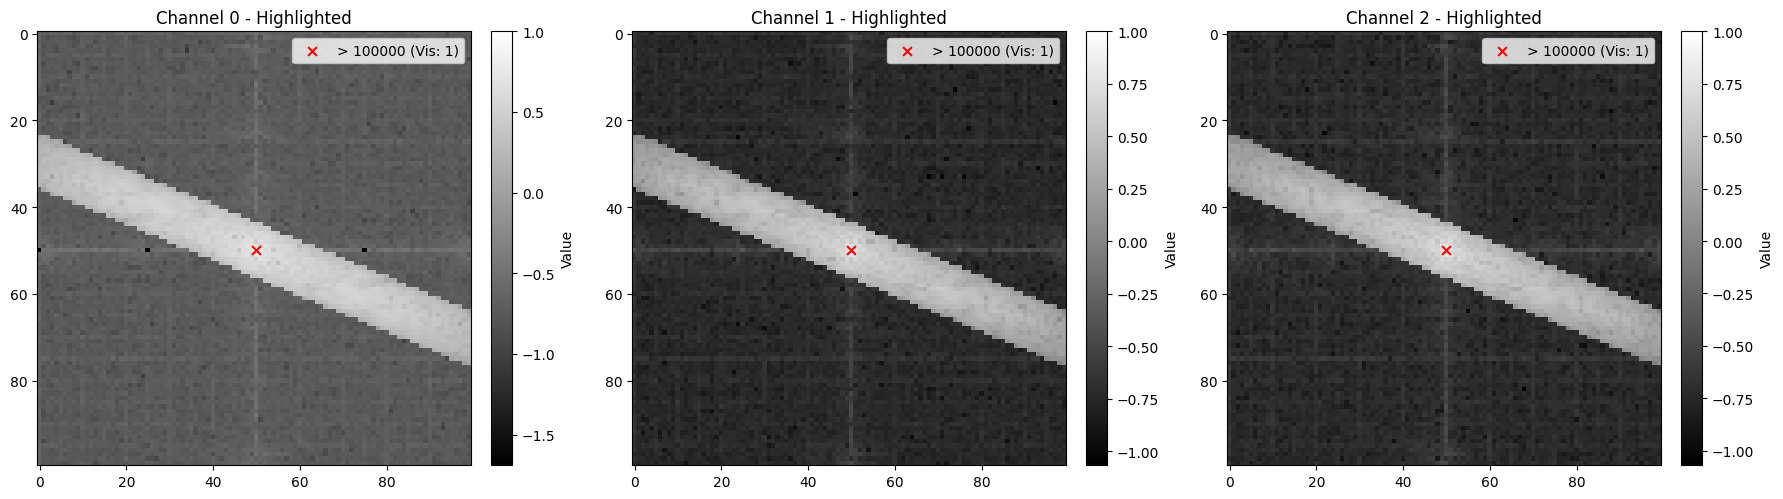

In [22]:
from matplotlib.colors import ListedColormap
import io

print("Max value in g_fft_2 before adding constant:", np.max(np.abs(g_fft_2)))
print("mean value in g_fft_2 before adding constant:", np.mean(np.abs(g_fft_2)))
print("Min value in g_fft_2 before adding constant:", np.min(np.abs(g_fft_2)))

data_3d = np.abs(g_fft_2)
threshold = 100000
mask_3d = data_3d > threshold

print(f"========== 阈值筛选统计结果 (Threshold = {threshold}) ==========")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

saved_plots_list = []

for ch in range(3):
    channel_data = data_3d[:, :, ch]
    channel_mask = mask_3d[:, :, ch]
    ax = axes[ch]
    pixel_count = np.sum(channel_mask)                     # 大于阈值的像素数目
    max_value = np.max(channel_data)                       # 当前通道的最大值
    if pixel_count > 0:
        mean_value = np.mean(channel_data[channel_mask])
    else:
        mean_value = 0.0
    print(f"\n[通道 {ch}]")
    print(f"  - 全局最大值: {max_value:.4f}")
    print(f"  - 大于阈值的像素数目: {pixel_count} 个 / 总像素 {channel_data.size} 个")
    print(f"  - 大于阈值像素的平均值: {mean_value:.4f}")
    
    orig_y, orig_x = np.where(channel_mask)
    if len(orig_x) > 0:
        # 将坐标打包成 (Y, X) 或者是 (row, col) 的元组列表
        orig_coords = list(zip(orig_y.tolist(), orig_x.tolist()))
        
        # 为了防止坐标太多刷屏，这里限制最多打印前 10 个
        max_print_num = 10
        coords_str = ", ".join([str(c) for c in orig_coords[:max_print_num]])
        
        if len(orig_coords) > max_print_num:
            print(f"  - 原图对应坐标 (Y, X): [{coords_str}, ... 等共 {len(orig_coords)} 个坐标]")
        else:
            print(f"  - 原图对应坐标 (Y, X): [{coords_str}]")
    else:
        print("  - 原图对应坐标 (Y, X): [] (无满足条件的像素)")
        
    plot_data = crop_center(fft_for_plot(channel_data), cropx=100, cropy=100) 
    im = ax.imshow(plot_data, cmap='gray', origin='upper')
    fig.colorbar(im, ax=ax, label='Value', fraction=0.046, pad=0.04)
    cropped_mask = crop_center(channel_mask, cropx=100, cropy=100)
    y_indices, x_indices = np.where(cropped_mask)
    if len(x_indices) > 0:
        ax.scatter(x_indices, y_indices, color='red', marker='x', s=40, 
                   label=f'> {threshold} (Vis: {len(x_indices)})')
        ax.legend(loc='upper right')
    ax.set_title(f'Channel {ch} - Highlighted')
plt.tight_layout()
plt.show()

Max value in g_fft_6 before adding constant: 976356.56
mean value in g_fft_6 before adding constant: 1.3974115
Min value in g_fft_6 before adding constant: 0.0
========== 阈值筛选统计结果 (Threshold = 100000) ==========

[通道 0]
  - 全局最大值: 830266.5625
  - 大于阈值的像素数目: 1 个 / 总像素 1440000 个
  - 大于阈值像素的平均值: 830266.5625
  - 原图对应坐标 (Y, X): [(600, 600)]

[通道 1]
  - 全局最大值: 913669.3750
  - 大于阈值的像素数目: 1 个 / 总像素 1440000 个
  - 大于阈值像素的平均值: 913669.3750
  - 原图对应坐标 (Y, X): [(600, 600)]

[通道 2]
  - 全局最大值: 976356.5625
  - 大于阈值的像素数目: 1 个 / 总像素 1440000 个
  - 大于阈值像素的平均值: 976356.5625
  - 原图对应坐标 (Y, X): [(600, 600)]


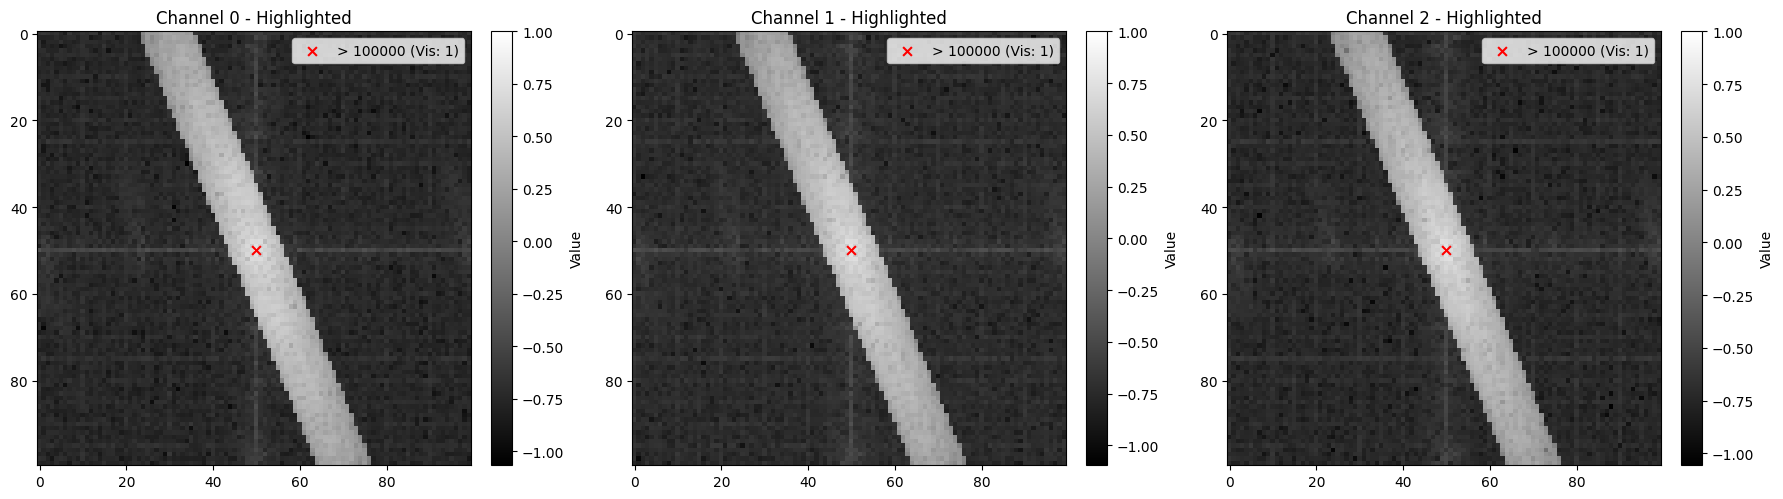

In [23]:
from matplotlib.colors import ListedColormap
import io

print("Max value in g_fft_6 before adding constant:", np.max(np.abs(g_fft_6)))
print("mean value in g_fft_6 before adding constant:", np.mean(np.abs(g_fft_6)))
print("Min value in g_fft_6 before adding constant:", np.min(np.abs(g_fft_6)))

data_3d = np.abs(g_fft_6)
threshold = 100000
mask_3d = data_3d > threshold

print(f"========== 阈值筛选统计结果 (Threshold = {threshold}) ==========")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

saved_plots_list = []

for ch in range(3):
    channel_data = data_3d[:, :, ch]
    channel_mask = mask_3d[:, :, ch]
    ax = axes[ch]
    pixel_count = np.sum(channel_mask)                     # 大于阈值的像素数目
    max_value = np.max(channel_data)                       # 当前通道的最大值
    if pixel_count > 0:
        mean_value = np.mean(channel_data[channel_mask])
    else:
        mean_value = 0.0
    print(f"\n[通道 {ch}]")
    print(f"  - 全局最大值: {max_value:.4f}")
    print(f"  - 大于阈值的像素数目: {pixel_count} 个 / 总像素 {channel_data.size} 个")
    print(f"  - 大于阈值像素的平均值: {mean_value:.4f}")
    
    orig_y, orig_x = np.where(channel_mask)
    if len(orig_x) > 0:
        # 将坐标打包成 (Y, X) 或者是 (row, col) 的元组列表
        orig_coords = list(zip(orig_y.tolist(), orig_x.tolist()))
        
        # 为了防止坐标太多刷屏，这里限制最多打印前 10 个
        max_print_num = 10
        coords_str = ", ".join([str(c) for c in orig_coords[:max_print_num]])
        
        if len(orig_coords) > max_print_num:
            print(f"  - 原图对应坐标 (Y, X): [{coords_str}, ... 等共 {len(orig_coords)} 个坐标]")
        else:
            print(f"  - 原图对应坐标 (Y, X): [{coords_str}]")
    else:
        print("  - 原图对应坐标 (Y, X): [] (无满足条件的像素)")
        
    plot_data = crop_center(fft_for_plot(channel_data), cropx=100, cropy=100) 
    im = ax.imshow(plot_data, cmap='gray', origin='upper')
    fig.colorbar(im, ax=ax, label='Value', fraction=0.046, pad=0.04)
    cropped_mask = crop_center(channel_mask, cropx=100, cropy=100)
    y_indices, x_indices = np.where(cropped_mask)
    if len(x_indices) > 0:
        ax.scatter(x_indices, y_indices, color='red', marker='x', s=40, 
                   label=f'> {threshold} (Vis: {len(x_indices)})')
        ax.legend(loc='upper right')
    ax.set_title(f'Channel {ch} - Highlighted')
plt.tight_layout()
plt.show()


[通道 0]
  - 最大值: 823465.8750
  - 平均值: 1.4774
  - 大于阈值的像素数目: 593623 个 / 总像素 1440000 个

[通道 1]
  - 最大值: 914505.5000
  - 平均值: 1.6529
  - 大于阈值的像素数目: 599602 个 / 总像素 1440000 个

[通道 2]
  - 最大值: 984022.8750
  - 平均值: 1.8674
  - 大于阈值的像素数目: 595443 个 / 总像素 1440000 个


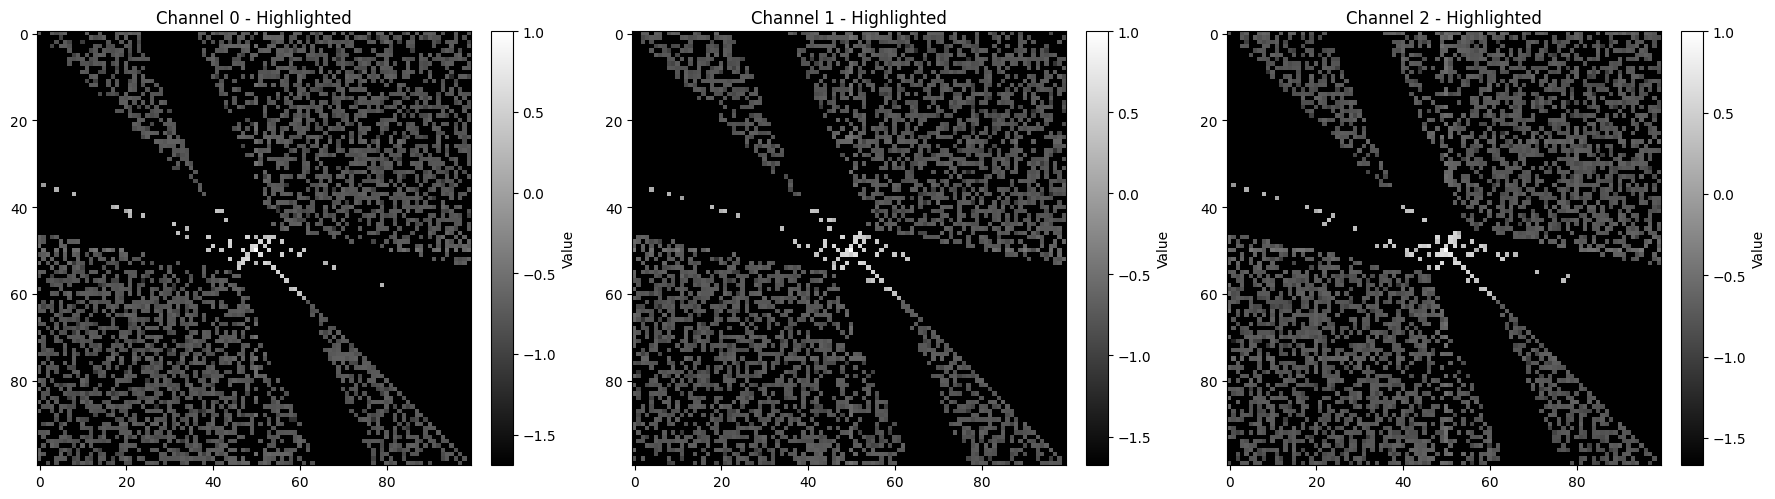

In [24]:
mag_103 = np.abs(g_fft_103)
mag_ap_2 = np.abs(g_fft_2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ch in range(3):
    diff, processed_arr, max_val, mean_val, count = compute_positive_diff(mag_ap_2[:, :, ch], mag_103[:, :, ch])
    print(f"\n[通道 {ch}]")
    print(f"  - 最大值: {max_val:.4f}")
    print(f"  - 平均值: {mean_val:.4f}")
    print(f"  - 大于阈值的像素数目: {count} 个 / 总像素 {mag_ap_2[:, :, ch].size} 个")
    ax = axes[ch]
    plot_data = crop_center(fft_for_plot(processed_arr), cropx=100, cropy=100) 
    im = ax.imshow(plot_data, cmap='gray', origin='upper')
    fig.colorbar(im, ax=ax, label='Value', fraction=0.046, pad=0.04)
    ax.set_title(f'Channel {ch} - Highlighted')
plt.tight_layout()
plt.show()


[通道 0]
  - 最大值: 824596.3750
  - 平均值: 1.9626
  - 大于阈值的像素数目: 452490 个 / 总像素 1440000 个

[通道 1]
  - 最大值: 916068.0000
  - 平均值: 2.1967
  - 大于阈值的像素数目: 452932 个 / 总像素 1440000 个

[通道 2]
  - 最大值: 986238.8750
  - 平均值: 2.4801
  - 大于阈值的像素数目: 449854 个 / 总像素 1440000 个


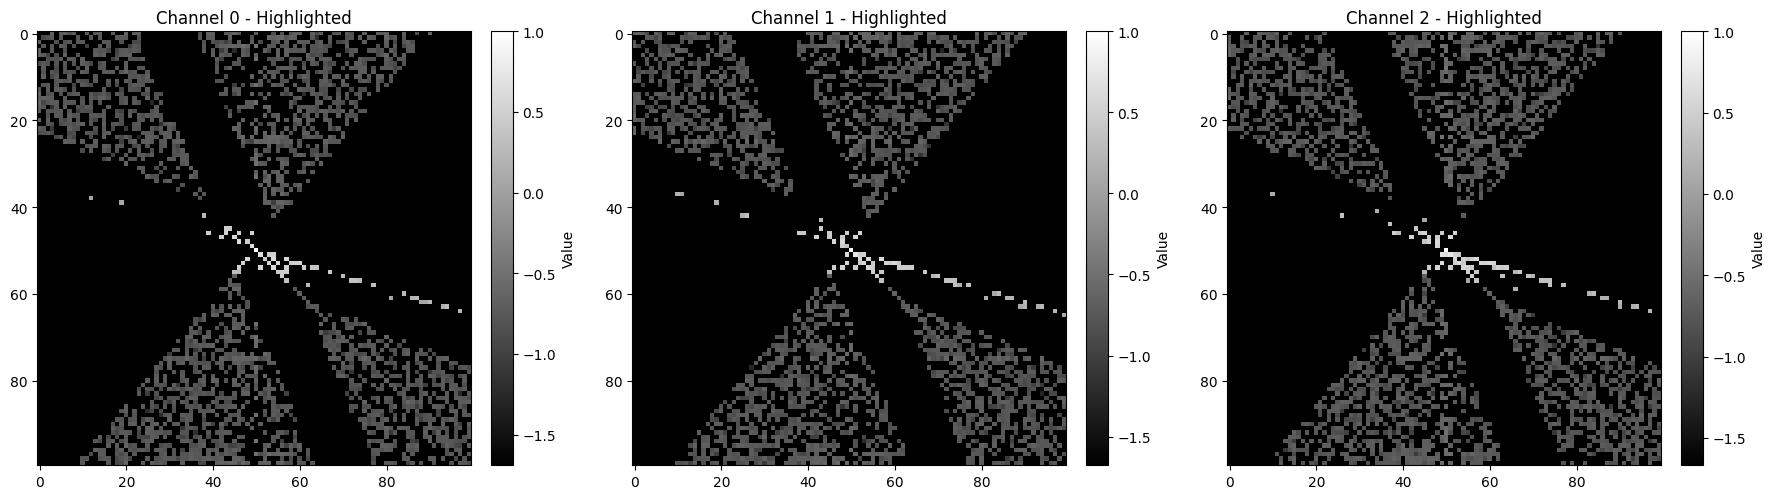

In [25]:
mag_103 = np.abs(g_fft_103)
mag_ap_1 = np.abs(g_fft_1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ch in range(3):
    diff, processed_arr, max_val, mean_val, count = compute_positive_diff(mag_ap_1[:, :, ch], mag_103[:, :, ch])
    print(f"\n[通道 {ch}]")
    print(f"  - 最大值: {max_val:.4f}")
    print(f"  - 平均值: {mean_val:.4f}")
    print(f"  - 大于阈值的像素数目: {count} 个 / 总像素 {mag_ap_1[:, :, ch].size} 个")
    ax = axes[ch]
    plot_data = crop_center(fft_for_plot(processed_arr), cropx=100, cropy=100) 
    im = ax.imshow(plot_data, cmap='gray', origin='upper')
    fig.colorbar(im, ax=ax, label='Value', fraction=0.046, pad=0.04)
    ax.set_title(f'Channel {ch} - Highlighted')
plt.tight_layout()
plt.show()


[通道 0]
  - 最大值: 830266.5625
  - 平均值: 2.2537
  - 大于阈值的像素数目: 393206 个 / 总像素 1440000 个

[通道 1]
  - 最大值: 913669.3750
  - 平均值: 2.4934
  - 大于阈值的像素数目: 388691 个 / 总像素 1440000 个

[通道 2]
  - 最大值: 976356.5625
  - 平均值: 2.6554
  - 大于阈值的像素数目: 393510 个 / 总像素 1440000 个


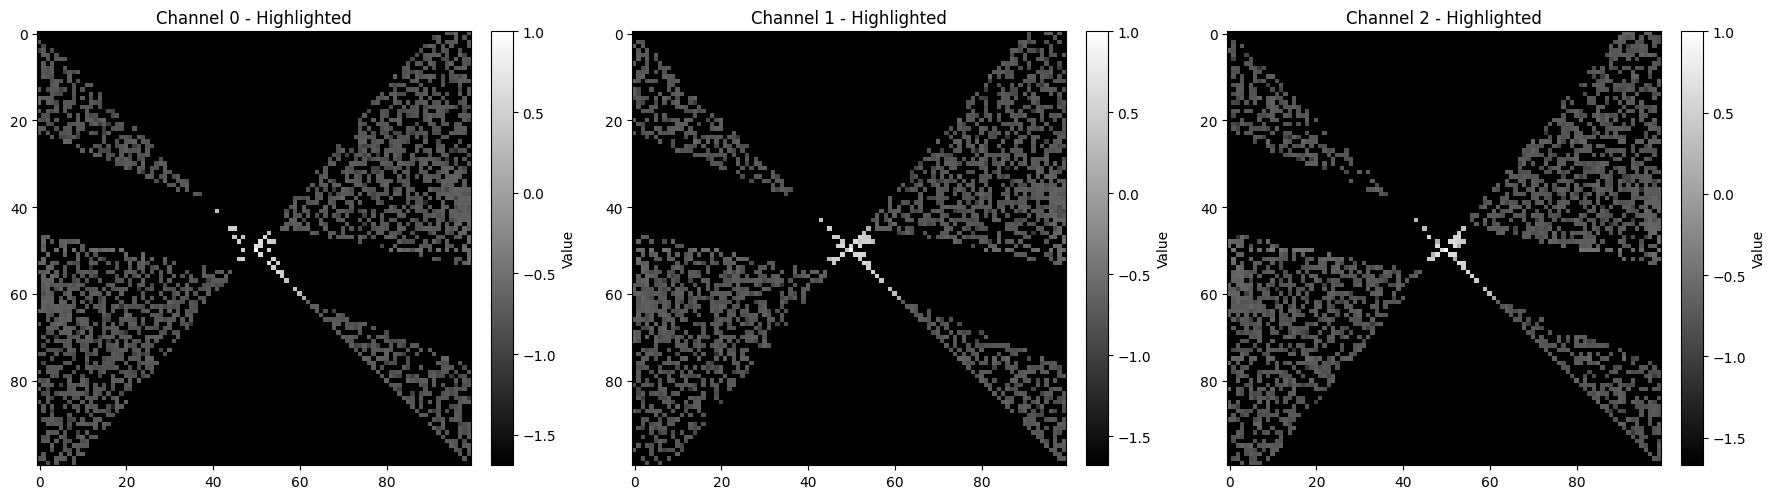

In [26]:
mag_103 = np.abs(g_fft_103)
mag_ap_6 = np.abs(g_fft_6)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ch in range(3):
    diff, processed_arr, max_val, mean_val, count = compute_positive_diff(mag_ap_6[:, :, ch], mag_103[:, :, ch])
    print(f"\n[通道 {ch}]")
    print(f"  - 最大值: {max_val:.4f}")
    print(f"  - 平均值: {mean_val:.4f}")
    print(f"  - 大于阈值的像素数目: {count} 个 / 总像素 {mag_ap_6[:, :, ch].size} 个")
    ax = axes[ch]
    plot_data = crop_center(fft_for_plot(processed_arr), cropx=100, cropy=100) 
    im = ax.imshow(plot_data, cmap='gray', origin='upper')
    fig.colorbar(im, ax=ax, label='Value', fraction=0.046, pad=0.04)
    ax.set_title(f'Channel {ch} - Highlighted')
plt.tight_layout()
plt.show()

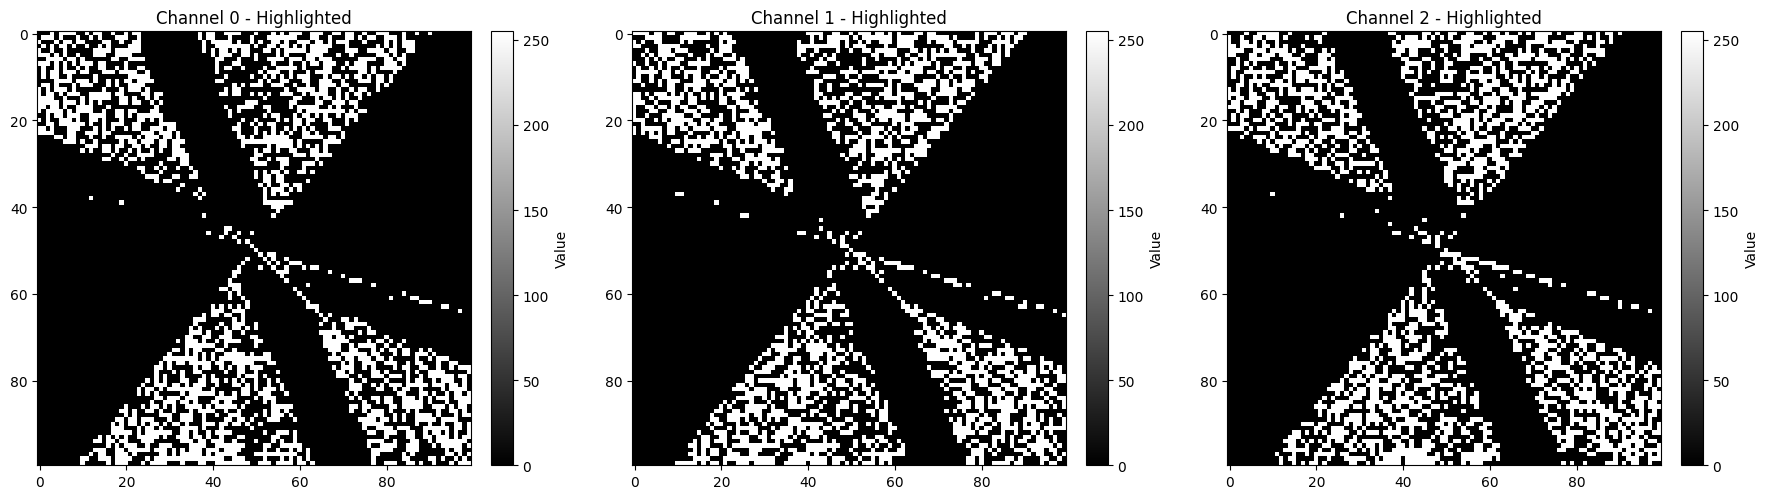

In [27]:
mag_103 = np.abs(g_fft_103)
mag_ap_1 = np.abs(g_fft_1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ch in range(3):
    diff, processed_arr, max_val, mean_val, count = compute_positive_diff(mag_ap_1[:, :, ch], mag_103[:, :, ch])
    h, w = mag_ap_1[:, :, ch].shape
    img_mask = np.zeros((h, w), dtype=np.uint8)
    mask = diff > 0
    img_mask[mask] = 255  # 将满足条件的像素设置为255，其他为0
    ax = axes[ch]
    plot_data = crop_center(img_mask, cropx=100, cropy=100) 
    im = ax.imshow(plot_data, cmap='gray', origin='upper')
    fig.colorbar(im, ax=ax, label='Value', fraction=0.046, pad=0.04)
    ax.set_title(f'Channel {ch} - Highlighted')
plt.tight_layout()
plt.show()


[通道 0]
  - 最大值: 7892.5273
  - 平均值: 0.0884
  - 大于阈值的像素数目: 386772 个 / 总像素 1440000 个

[通道 1]
  - 最大值: 18302.2070
  - 平均值: 0.1752
  - 大于阈值的像素数目: 388274 个 / 总像素 1440000 个

[通道 2]
  - 最大值: 26604.7461
  - 平均值: 0.3048
  - 大于阈值的像素数目: 383535 个 / 总像素 1440000 个


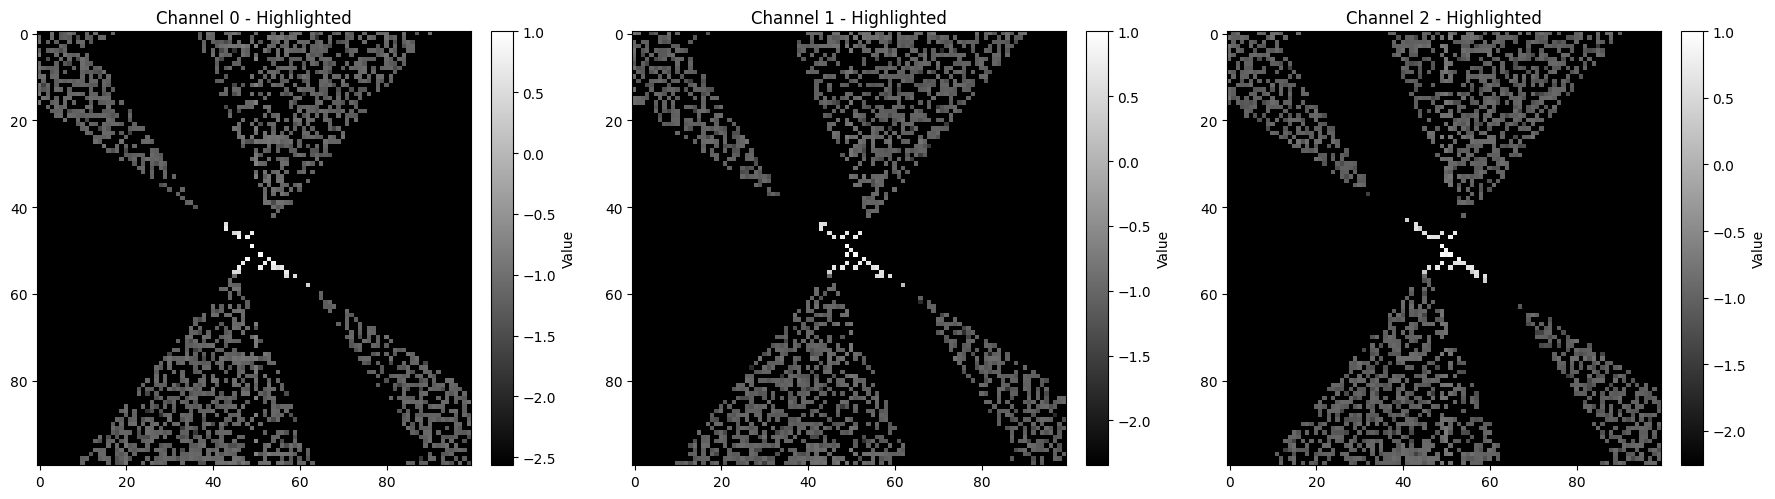

In [28]:
mag_99 = np.abs(g_fft_99) # 99:1,5,6
mag_ap_1 = np.abs(g_fft_1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ch in range(3):
    diff, processed_arr, max_val, mean_val, count = compute_positive_diff(mag_ap_1[:, :, ch], mag_99[:, :, ch])
    print(f"\n[通道 {ch}]")
    print(f"  - 最大值: {max_val:.4f}")
    print(f"  - 平均值: {mean_val:.4f}")
    print(f"  - 大于阈值的像素数目: {count} 个 / 总像素 {mag_ap_1[:, :, ch].size} 个")
    ax = axes[ch]
    plot_data = crop_center(fft_for_plot(processed_arr), cropx=100, cropy=100) 
    im = ax.imshow(plot_data, cmap='gray', origin='upper')
    fig.colorbar(im, ax=ax, label='Value', fraction=0.046, pad=0.04)
    ax.set_title(f'Channel {ch} - Highlighted')
plt.tight_layout()
plt.show()


[通道 0]
  - 最大值: 15855.9004
  - 平均值: 0.1632
  - 大于阈值的像素数目: 475731 个 / 总像素 1440000 个

[通道 1]
  - 最大值: 6832.1255
  - 平均值: 0.1432
  - 大于阈值的像素数目: 472936 个 / 总像素 1440000 个

[通道 2]
  - 最大值: 9100.6641
  - 平均值: 0.1442
  - 大于阈值的像素数目: 477216 个 / 总像素 1440000 个


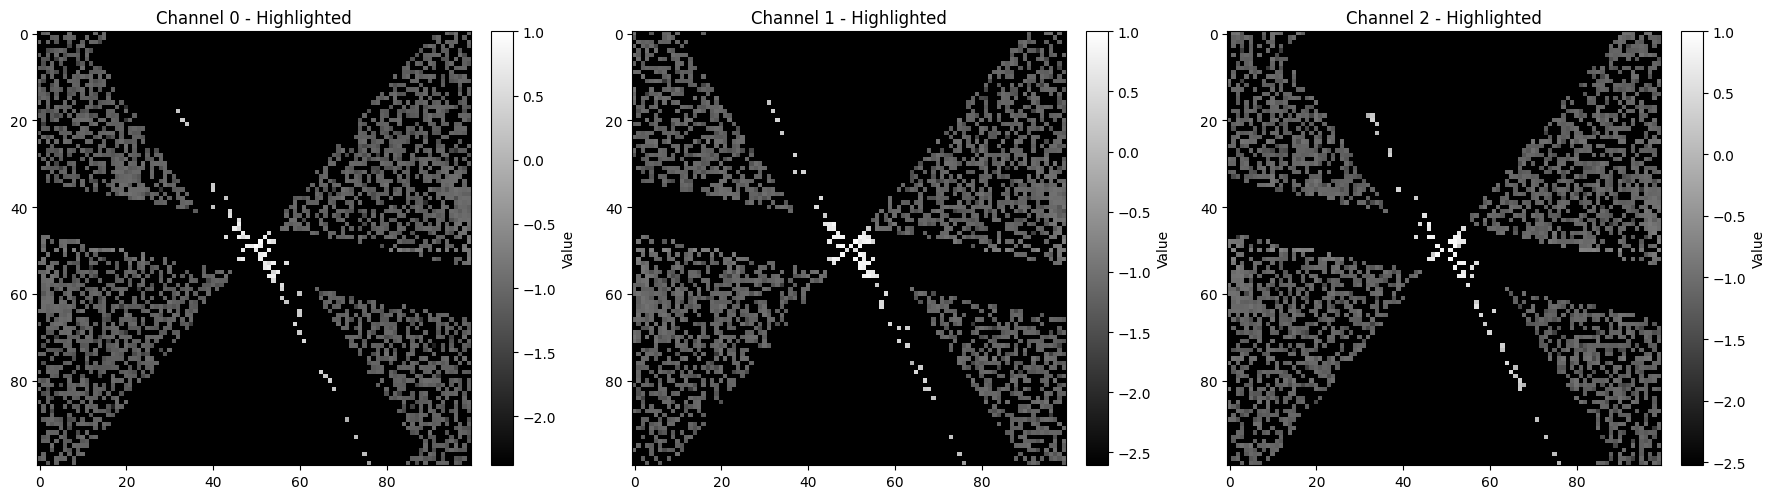

In [67]:
mag_99 = np.abs(g_fft_99) # 99:1,5,6
mag_ap_6 = np.abs(g_fft_6)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ch in range(3):
    diff, processed_arr, max_val, mean_val, count = compute_positive_diff(mag_ap_6[:, :, ch], mag_99[:, :, ch])
    print(f"\n[通道 {ch}]")
    print(f"  - 最大值: {max_val:.4f}")
    print(f"  - 平均值: {mean_val:.4f}")
    print(f"  - 大于阈值的像素数目: {count} 个 / 总像素 {mag_ap_6[:, :, ch].size} 个")
    ax = axes[ch]
    plot_data = crop_center(fft_for_plot(processed_arr), cropx=100, cropy=100) 
    im = ax.imshow(plot_data, cmap='gray', origin='upper')
    fig.colorbar(im, ax=ax, label='Value', fraction=0.046, pad=0.04)
    ax.set_title(f'Channel {ch} - Highlighted')
plt.tight_layout()
plt.show()

In [29]:
test = g_fft_103.copy()
for ch in range(3):
    value = (g_fft_1[600,600,ch] + g_fft_2[600,600,ch] + g_fft_6[600,600,ch]) / 3
    test[600, 600, ch] = value


    

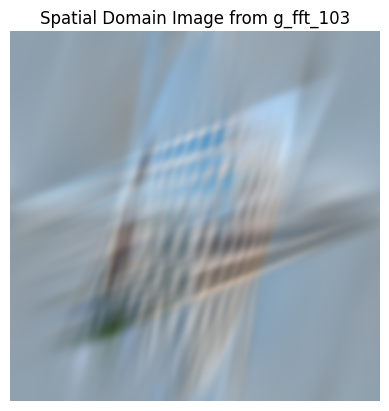

Max value in spatial_test: 0.9496851


In [30]:
spatial_test = np.abs(ifft2(ifftshift(test, axes=(0, 1)), axes=(0, 1)))
fft_back = fftshift(fft2(spatial_test, axes=(0, 1)), axes=(0, 1))
plt.imshow(spatial_test)
plt.axis('off')  # 不显示坐标轴 
plt.title('Spatial Domain Image from g_fft_103')
plt.show()

print("Max value in spatial_test:", np.max(spatial_test))

In [27]:
# Calculate the weight stack and contributing indices for each pixel
'''
weight_stack: A 3D boolean array of shape (N, H, W) where N is the number of angles. Each slice weight_stack[i] is a 2D boolean mask indicating which pixels are covered by the
total_weight_map: A 2D array of shape (H, W) where each pixel's value indicates how many masks (angles) cover that pixel. This is essentially the sum of the boolean masks across the first dimension.
contributing_indices: A 2D object array of shape (H, W) where each entry is a tuple containing the indices of the angles that contribute to that pixel. For example, contributing
_indices[r, c] might be (0, 2, 5) indicating that the masks from angles 0, 2, and 5 cover the pixel at row r and column c.
'''
# --- Build the stacked mask array ---

# Stack all masks into a single (N, H, W) boolean array
weight_stack = np.zeros((N_APERTURES, C_SIZE, C_SIZE), dtype=bool)

for i, phi in enumerate(ANGLES):
    _single_map = get_single_weight_map(phi, L=LENGTH, W=WIDTH, canvas_size=C_SIZE)
    weight_stack[i] = _single_map > 0

# Total weight map: how many masks cover each pixel
TOTAL_WEIGHT_MAP = weight_stack.sum(axis=0).astype(np.float32)  # shape (H, W)

# For ALL pixels, build a (H, W) object array where each entry
# is a tuple of contributing angle indices
contributing_indices = np.empty((C_SIZE, C_SIZE), dtype=object)

# Vectorized approach: transpose to (H, W, N) and use argwhere-style logic
weight_HWN = weight_stack.transpose(1, 2, 0)  # (H, W, N)

# Find all pixels that have at least one mask (skip pure-black borders)
active_pixels = TOTAL_WEIGHT_MAP > 0
rows, cols = np.where(active_pixels)

for r, c in zip(rows, cols):
    contributing_indices[r, c] = tuple(np.where(weight_HWN[r, c])[0])

In [28]:
# Encode each pixel's combination as a hashable tuple, then map to group IDs
group_map_ori = {}
GROUP_ID_ARR = np.zeros((C_SIZE, C_SIZE), dtype=np.int32)
counter = 1

for r, c in zip(rows, cols):
    key = tuple(int(i) for i in np.where(weight_HWN[r, c])[0])
    if key not in group_map_ori:
        group_map_ori[key] = counter
        counter += 1
    GROUP_ID_ARR[r, c] = group_map_ori[key]

# group_map_ori: {(0,): 0, (0, 1): 1, (0, 1, 2): 2, ...}
# GROUP_ID_ARR: (1200, 1200) int array, each pixel labeled by its group
# GROUP_MAP: {0: (0,), 1: (0, 1), 2: (0, 1, 2), ...}
# Build reverse mapping: from group_id to angle indices
GROUP_MAP = {v: k for k, v in group_map_ori.items()}
GROUP_MAP[0] = None  # Group 0 corresponds to pixels with no coverage (black borders)



In [29]:
def query_pixel(r, c, id_array=GROUP_ID_ARR, group_mapping=GROUP_MAP):
    pixel_group = id_array[r, c]
    if pixel_group == 0:
        print("This pixel is not covered by any mask")
    else:
        print(f"Group ID: {pixel_group}, Contributing angle indices: {group_mapping[pixel_group]}")
    return pixel_group, group_mapping[int(pixel_group)]

def px_in_group(target_group, id_array=GROUP_ID_ARR, map=GROUP_MAP):
    ys, xs = np.where(id_array == target_group)
    return list(zip(ys.tolist(), xs.tolist())), map[target_group]

def get_actual_angle(angle_indices, angle_list=ANGLES):
    return [float(angle_list[i]) for i in angle_indices]

def tup_2_list(angle_indices_tuple):
    return list(angle_indices_tuple)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


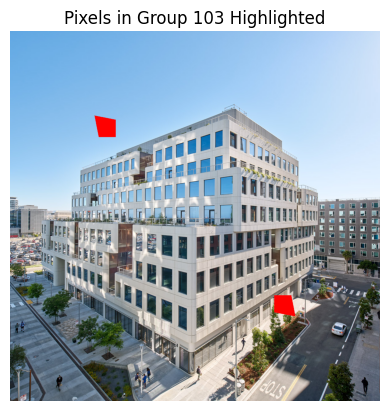

In [50]:
mask, _ = px_in_group(155)
IMG = GT_IMG.copy()

for y, x in mask:
    IMG[y, x] = [255, 0, 0]
    
plt.imshow(IMG)
plt.axis('off')  # 不显示坐标轴
plt.title('Pixels in Group 103 Highlighted')
plt.show()